**NLP TEXT CLASSIFIER**


---
*Product Review Sentiment Classifier — classify a user's text as Positive, Neutral, or Negative and display class probabilities.*


**LOAD AND INSPECT DATASET**

In [2]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df["label"].value_counts())

df.isnull().sum()
df.duplicated().sum()

                                                text     label
0  The mouse pad exceeded my expectations and fel...  positive
1  The seller listed the coffee maker with severa...   neutral
2  Overall, I am very unhappy with the running sh...  negative
3  Using the mobile phone case has been a genuine...  positive
4  The portable charger performs poorly and looks...  negative
(2000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB
None
label
positive    667
negative    667
neutral     666
Name: count, dtype: int64


np.int64(0)

**TEXT CLEANING**

In [5]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

**REMOVE BAD RECORDS**

In [7]:
df = df.dropna(subset=["clean_text", "label"])

df = df[df["clean_text"].str.len() > 2]

df = df.drop_duplicates(subset=["clean_text"])

print(df["label"].value_counts())

label
negative    657
positive    650
neutral     536
Name: count, dtype: int64


**VISUALIZATION**

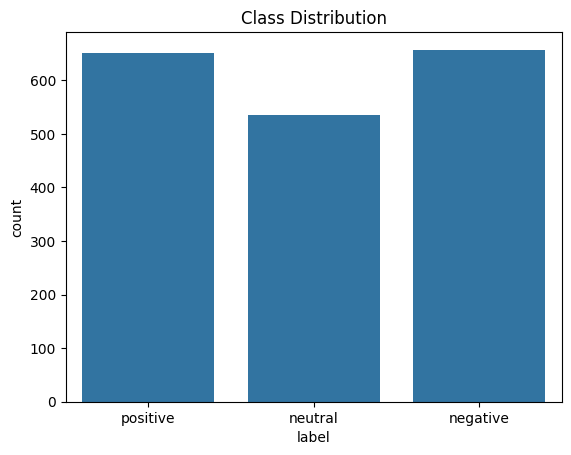

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

**TRAIN AND TEST SPILIT**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

**CONVERT TEXT INTO NUMBER (TF- IDF)**

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=20000
)

**MODEL-1) TF-IDF + LOGISTIC REGRESSION IMPLEMENTED AS PIPELINE**

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=20000
    )),

    ("classifier", LogisticRegression(
        max_iter=2000
    ))
])

**MODEL-2) TF-IDF + MULTINOMIAL NAIVE BYES IMPLEMENTED AS PIPELINE**

In [24]:
from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000
    )),
    ("classifier", MultinomialNB())
])



**TRAINING**

In [26]:
model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                ('classifier', MultinomialNB())])

**PREDICTION**

In [28]:
# PREIDCTION OF MODEL-1
pred = model.predict(X_test)

probabilities = model.predict_proba(X_test)

# PREDICTION OF MODEL-2
nb_pred = nb_model.predict(X_test)

# FOR A SINGLE SENTENCE
text = ["The product is excellent and worth the money"]

prediction_1 = model.predict(text)[0]

probability_2 = model.predict_proba(text)[0]

prediction_2 = nb_model.predict(text)[0]

probability_2 = nb_model.predict_proba(text)[0]

print("MODEL-1 PREDICTION:->>", prediction_1)
print("MODEL-1 PROBABILITY:->>", probability_2)
print("MODEL-2 PREDICTION:->>", prediction_2)
print("MODEL-2 PROBABILITY:->>", probability_2)

MODEL-1 PREDICTION:->> positive
MODEL-1 PROBABILITY:->> [0.04832907 0.07740042 0.8742705 ]
MODEL-2 PREDICTION:->> positive
MODEL-2 PROBABILITY:->> [0.04832907 0.07740042 0.8742705 ]


**EVALUATION METRICS**

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, pred))

print("Precision:",
      precision_score(
          y_test,
          pred,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          pred,
          average="weighted"
      ))

print("F1:",
      f1_score(
          y_test,
          pred,
          average="weighted"
      ))

print(classification_report(y_test, pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       132
     neutral       1.00      1.00      1.00       107
    positive       1.00      1.00      1.00       130

    accuracy                           1.00       369
   macro avg       1.00      1.00      1.00       369
weighted avg       1.00      1.00      1.00       369



**CONFUSION MATRIX**

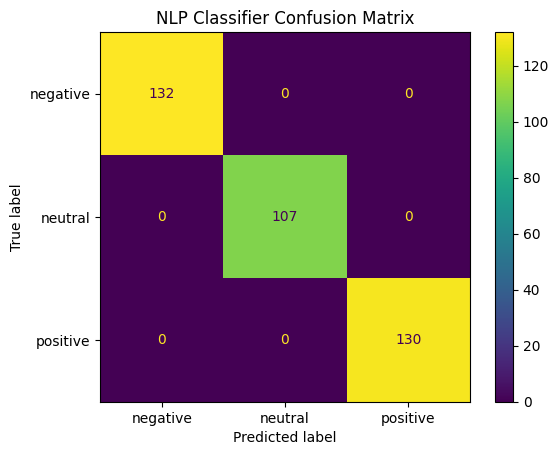

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.title("NLP Classifier Confusion Matrix")
plt.show()

**SAVING THE MODEL**

In [20]:
import joblib

joblib.dump(
    model,
    "sentiment_pipeline.joblib"
)

# TEST
loaded_model = joblib.load(
    "sentiment_pipeline.joblib"
)

text = ["This is a fantastic product"]

print(
    loaded_model.predict(text)
)

['positive']
